# Fitting API example

Runs `ellipse_fitting.detect_ellipse` against a saved video and looks at rolling stability metrics from `stability_metrics`, independent of `camera_server.py`.

## Setup

Makes `src/` importable and loads a `Config` from `calibration_example.json` — the same config `camera_server.py` runs with.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd
import cv2
import dataclasses
import json
from matplotlib.patches import Rectangle, Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable

from stability_metrics import rolling_mean, rolling_rms_deviation, rolling_volume_stability
from ellipse_fitting import Config, detect_ellipse, binarize

with open("../calibration_example.json") as f:
    raw = json.load(f)
field_names = {f.name for f in dataclasses.fields(Config)}
config = Config(**{k: v for k, v in raw.items() if k in field_names})

## Single-frame check

Reads the first frame and runs `binarize`/`detect_ellipse` on it (the full frame — `binarize` itself doesn't crop to ROI). Plots the raw frame with the ROI box overlaid (left) next to the full-frame binary mask with the fitted ellipse overlaid (right), as a sanity check that `config` is tuned for this video before running a full pass.

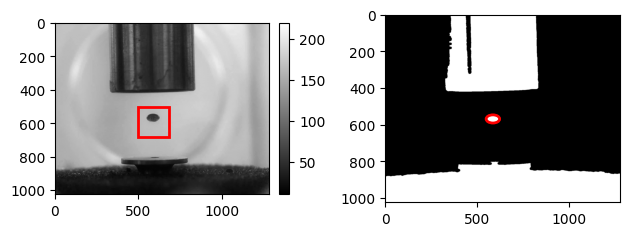

In [2]:
cap = cv2.VideoCapture("../250326205936462.avi")

ret, frame = cap.read()
binary = binarize(frame, config)
measurement, ellipse = detect_ellipse(frame, config)

fig, (ax1, ax2) = plt.subplots(1, 2)
pl1 = ax1.imshow(frame.mean(2), cmap="gray")
pl2 = ax2.imshow(binary, cmap="gray", aspect="equal")
rectangle_patch = Rectangle(xy=(config.roi[0], config.roi[1]), width=config.roi[2], height=config.roi[3], edgecolor="r", facecolor="none", lw=2)
ax1.add_patch(rectangle_patch)
ellipse_patch = Ellipse(xy=ellipse[0], width=ellipse[1][1], height=ellipse[1][0], edgecolor="r", facecolor="none", lw=2)
ax2.add_patch(ellipse_patch)
divider = make_axes_locatable(ax1)
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(pl1, cax=cax)
fig.tight_layout()
plt.show()

cap.release()

## Batch fit

Steps through up to 10000 frames of the video, running `detect_ellipse` on every 10th frame, and collects the per-frame measurements into `results` (`None` for frames with no fit).

In [3]:
cap = cv2.VideoCapture("../250326205936462.avi")
results = []
for i in range(0, 10000):
    ret, frame = cap.read()
    if not ret:
        break
    if i%10 == 0:
        measurement, ellipse = detect_ellipse(frame, config)
        results.append(measurement)
cap.release()

## Rolling stability plots

Replaces frames with `volume_mm3 >= 10` (bad fits) with `None`, then computes rolling mean/RMS position and rolling mean/CV volume from `stability_metrics` on the filtered list, so the timestamps returned alongside each series line up by construction. Plots center position (dual y-axis, x in blue / y in red) and volume, each shaded by ±rolling RMS or CV as a stability band.

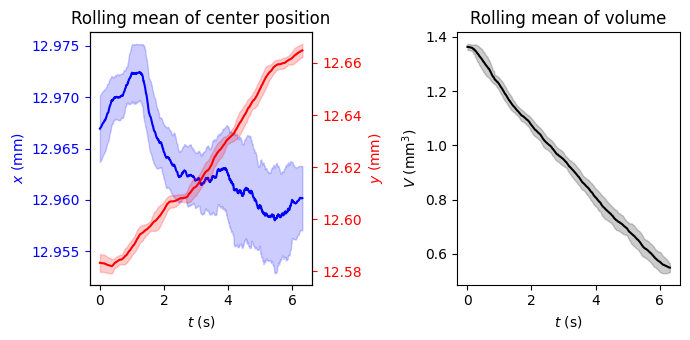

In [5]:
t0 = next(m["timestamp"] for m in results if m is not None)
results_filtered = [
    m if (m is not None and m["volume_mm3"] < 10) else None
    for m in results
]

t_abs, cx_mean = rolling_mean(results_filtered, "cx_mm", window_s=0.5)
_, rms_x = rolling_rms_deviation(results_filtered, "cx_mm", window_s=0.5)
_, cy_mean = rolling_mean(results_filtered, "cy_mm", window_s=0.5)
_, rms_y = rolling_rms_deviation(results_filtered, "cy_mm", window_s=0.5)
_, volume_mean = rolling_mean(results_filtered, "volume_mm3", window_s=0.5)
_, volume_stab = rolling_volume_stability(results_filtered, window_s=0.5)
t_rel = t_abs - t0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(2*3.5, 3.5))
# ax1.plot(t_rel, rms_x)
ax1.plot(t_rel, cx_mean, color="b")
ax1.fill_between(t_rel, cx_mean-rms_x, cx_mean+rms_x, color="b", alpha=0.2)
ax1.set_xlabel(r"$t~$(s)")
ax1.set_ylabel(r"$x~$(mm)", color="b")
ax1.tick_params("y", color="b", labelcolor="b")
ax1_1 = ax1.twinx()
ax1_1.plot(t_rel, cy_mean, color="r")
ax1_1.fill_between(t_rel, cy_mean-rms_y, cy_mean+rms_y, color="r", alpha=0.2)
ax1_1.set_ylabel(r"$y~$(mm)", color="r")
ax1_1.tick_params("y", color="r", labelcolor="r")
ax1.set_title("Rolling mean of center position")
ax2.plot(t_rel, volume_mean, '-k')
ax2.fill_between(t_rel, volume_mean-volume_stab, volume_mean+volume_stab, color='k', alpha=0.2)
ax2.set_xlabel(r"$t~$(s)")
ax2.set_ylabel(r"$V~$(mm$^3$)")
ax2.set_title("Rolling mean of volume")
fig.tight_layout()
plt.show()